### Step 1: Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

### Step 2: Load Dataset

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Step 3: Separate Input & Output

In machine learning, we separate the dataset into X (input features) and y (target/output) so the model can learn to predict outcomes. When we write X = df.drop("Outcome", axis=1), we are not deleting the column from the original dataset, but only creating a new dataset (X) without the Outcome column. The original dataframe df still contains Outcome, which is why we can safely write y = df["Outcome"]. This separation is important because the model should learn from inputs (X) to predict the output (y), not already see the answer.

In [3]:
X = df.drop("Outcome" , axis = 1)    #features
y = df["Outcome"]                    #Target

### Step 4: Train-Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2)

Means:
- 80% data → training
- 20% data → testing

### Step 5: Train Model

In [5]:
model = LogisticRegression(max_iter =200)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


While running Logistic Regression, I encountered a ConvergenceWarning indicating that the model failed to converge within the default 100 iterations. This happens when the model does not get enough iterations to find the optimal solution, often due to unscaled data or complex feature relationships. To resolve this, **Option 1** - I increased the number of iterations using **max_iter=200** and **Option2** is to apply feature scaling using StandardScaler. After these changes, the model trained properly without warnings and gave better performance.

I used Option 1 and it worked !

### Step 6: Prediction

In [6]:
y_pred = model.predict(X_test)

### Step 7: Accuracy

In [7]:
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy : ", accuracy)

Accuracy :  0.7922077922077922


Means - 79.22% predictions are correct

### Confusion Matrix 

In [8]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[84 12]
 [20 38]]


If we want to see it !

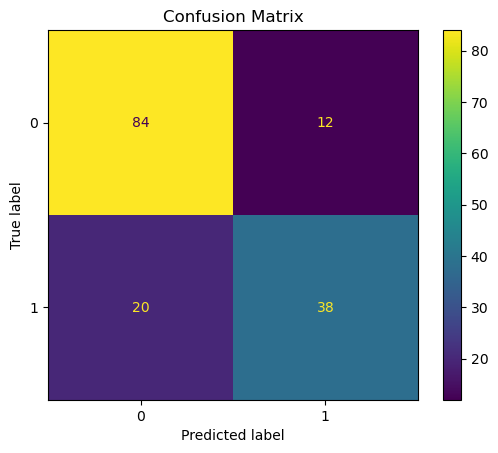

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

### If we want BOTH input + output together

In [11]:
test_data = X_test.copy()
test_data["Actual Outcome"] = y_test
test_data["Predicted Outcome"] = y_pred
test_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual Outcome,Predicted Outcome
340,1,130,70,13,105,25.9,0.472,22,0,0
485,0,135,68,42,250,42.3,0.365,24,1,0
594,6,123,72,45,230,33.6,0.733,34,0,0
444,4,117,62,12,0,29.7,0.380,30,1,0
653,2,120,54,0,0,26.8,0.455,27,0,0


## I want to give the values manually then check the output. Let's Try !

#### 1. Important: Input format
Your model expects 8 values:
[Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age]

#### 2. Give input manually

In [12]:
new_data = [[2, 120, 70, 25, 80, 30.5, 0.5, 35]]

#### 3. Predict output

In [13]:
prediction = model.predict(new_data)
print(prediction)

[0]


C:\Users\ISHA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [14]:
# If we want the Output in a good format !
if prediction[0] == 1:
    print("Patient has Diabetes")
else:
    print("Patient does NOT have Diabetes")

Patient does NOT have Diabetes


🔷 What this warning means
- You trained the model using a DataFrame (with column names)
- But while predicting, you gave input as a simple list (without names)

#### Solution is - 
Give input as a DataFrame with same column names

In [15]:
import pandas as pd

new_data = pd.DataFrame([[2, 120, 70, 25, 80, 30.5, 0.5, 35]],
columns=["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
)

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("Patient has Diabetes")
else:
    print("Patient does NOT have Diabetes")

Patient does NOT have Diabetes
